# K-shell Algorithm

This file is an experiment to verify the stability of the K-shell algorithm.

Before running this program, please make sure to run Topic_Modeling.ipynb to generate the necessary intermediate files.

In [3]:
import os
import json
import random
import numpy as np
import networkx as nx
from collections import defaultdict, Counter
from itertools import combinations
from multiprocessing import Pool, cpu_count
import matplotlib.pyplot as plt

def keyword_stability_experiment(paper_keywords, a, t, random_seed=42):
    """
    Compare stability between K-shell and dynamic-count baseline algorithms
    
    Args:
        paper_keywords (list): List of paper keywords (each paper is list of keyword dicts)
        a (float): Proportion of papers to remove in each simulation
        t (int): Number of simulation runs
        random_seed (int): Seed for random number generator
        
    Returns:
        tuple: (k_shell_stability, dynamic_count_stability)
    """
    random.seed(random_seed)
    total_papers = len(paper_keywords)
    remove_count = int(total_papers * a)
    remaining_count = total_papers - remove_count

    # Precompute display names once
    display_names = []
    for paper in paper_keywords:
        if paper and isinstance(paper[0], dict):
            display_names.append([kw['display_name'] for kw in paper])
        else:
            display_names.append(paper)
    
    # Precompute all possible edges
    all_edges = set()
    for paper in display_names:
        if len(paper) > 1:
            all_edges.update(combinations(paper, 2))

    k_shell_results = []
    dynamic_count_results = []

    for sim in range(t):
        # Unique seed per simulation
        sim_seed = random.randint(0, 2**32 - 1)
        rng = random.Random(sim_seed)
        
        # Random selection
        indices = list(range(total_papers))
        rng.shuffle(indices)
        selected = indices[:remaining_count]
        subset = [display_names[i] for i in selected]
        
        # Frequency calculation
        flat_keywords = [kw for paper in subset for kw in paper]
        freq = Counter(flat_keywords)
        
        # K-shell calculation
        H = nx.Graph()
        edges = []
        for paper in subset:
            if len(paper) > 1:
                edges.extend(combinations(paper, 2))
        H.add_edges_from(edges)
        
        H.remove_edges_from(nx.selfloop_edges(H))
        
        if H.number_of_nodes() == 0:
            k_shell = set()
        else:
            core_numbers = nx.core_number(H)
            max_core = max(core_numbers.values()) if core_numbers else 0
            k_shell = {k for k, v in core_numbers.items() if v == max_core}
        k_shell_results.append(k_shell)
        
        # Dynamic count baseline
        k = len(k_shell)
        if k == 0:
            dynamic_selected = set()
        else:
            sorted_keywords = sorted(freq.items(), key=lambda x: (-x[1], x[0]))
            dynamic_selected = {kw for kw, cnt in sorted_keywords[:k]}
        dynamic_count_results.append(dynamic_selected)

    # Calculate stability metric: always/(always + sometimes)
    def calculate_stability(results):
        counter = defaultdict(int)
        for res in results:
            for kw in res:
                counter[kw] += 1
        
        always = sum(1 for cnt in counter.values() if cnt == t)
        sometimes = sum(1 for cnt in counter.values() if 0 < cnt < t)
        
        return always / (always + sometimes) if (always + sometimes) > 0 else 0.0

    return calculate_stability(k_shell_results), calculate_stability(dynamic_count_results)

def process_window(params):
    """
    Process a single time window with guaranteed reproducibility
    """
    (year_range, window_papers, a, t, window_seed) = params
    
    # Ensure deterministic processing
    random.seed(window_seed)
    np.random.seed(window_seed)
    
    # Run experiment
    return keyword_stability_experiment(
        window_papers,
        a=a,
        t=t,
        random_seed=window_seed
    )

def run_stability_analysis(a, t, sep=5, random_seed=42, num_processes=None, file_path="topics"):
    """
    Perform stability analysis across multiple time windows for all topics
    
    Args:
        a (float): Proportion of papers to remove in each simulation
        t (int): Number of simulation runs per time window
        sep (int): Year span for time windows (default=5)
        random_seed (int): Seed for random number generator
        num_processes (int): Number of parallel processes (None for auto)
        
    Returns:
        dict: Contains mean and variance for both algorithms
    """
    random.seed(random_seed)
    np.random.seed(random_seed)
    
    if num_processes is None:
        num_processes = cpu_count()
    
    # Prepare all tasks
    tasks = []
    
    # Process each topic file
    for filename in os.listdir(f'./{file_path}'):
        if not filename.endswith('.txt'):
            continue
            
        # Load topic data
        with open(os.path.join(f'./{file_path}', filename), 'r') as f:
            data = json.load(f)
            years = data['topic_year']
            keywords = data['topic_keyword']
            
            # Skip empty topics
            if not years:
                continue
                
            # Generate time windows
            start_year = min(years)
            end_year = max(years)
            year_ranges = []
            for y in range(end_year + 1, start_year - 1, -sep):
                year_ranges.append((y, y + sep))
            year_ranges = sorted(year_ranges, key=lambda x: x[0])
            
            # Precompute display names once per topic
            topic_display_names = []
            for paper in keywords:
                if paper and isinstance(paper[0], dict):
                    topic_display_names.append([kw['display_name'] for kw in paper])
                else:
                    topic_display_names.append(paper)
            
            # Create tasks for each window
            for year_range in year_ranges:
                # Filter papers in current window [start, end)
                filtered_indices = [
                    i for i, y in enumerate(years) 
                    if year_range[0] <= y < year_range[1]
                ]
                
                # Skip empty windows
                if not filtered_indices:
                    continue
                    
                # Prepare keyword list
                window_papers = [topic_display_names[i] for i in filtered_indices]
                
                # Generate unique seed for this window
                window_seed = random.randint(0, 2**32 - 1)
                
                # Add to task queue
                tasks.append((
                    year_range,
                    window_papers,
                    a,
                    t,
                    window_seed
                ))
    
    # Parallel processing with reproducibility
    with Pool(processes=num_processes) as pool:
        results = pool.map(process_window, tasks)
    
    # Unpack results
    k_shell_stabilities, dynamic_count_stabilities = zip(*results)
    
    # Calculate and return statistics
    return {
        'k_shell': {
            'mean': np.mean(k_shell_stabilities),
            'variance': np.var(k_shell_stabilities)
        },
        'dynamic_count': {
            'mean': np.mean(dynamic_count_stabilities),
            'variance': np.var(dynamic_count_stabilities)
        }
    }
    
run_stability_analysis(a=0.001, t=5)

{'k_shell': {'mean': np.float64(0.995093656143247),
  'variance': np.float64(0.00464205310943798)},
 'dynamic_count': {'mean': np.float64(0.995093656143247),
  'variance': np.float64(0.00464205310943798)}}

Processing a=0.0100
Processing a=0.0165
Processing a=0.0271
Processing a=0.0447
Processing a=0.0737
Processing a=0.1214
Processing a=0.2000
Processing a=0.0100
Processing a=0.0165
Processing a=0.0271
Processing a=0.0447
Processing a=0.0737
Processing a=0.1214
Processing a=0.2000
Processing a=0.0100
Processing a=0.0165
Processing a=0.0271
Processing a=0.0447
Processing a=0.0737
Processing a=0.1214
Processing a=0.2000


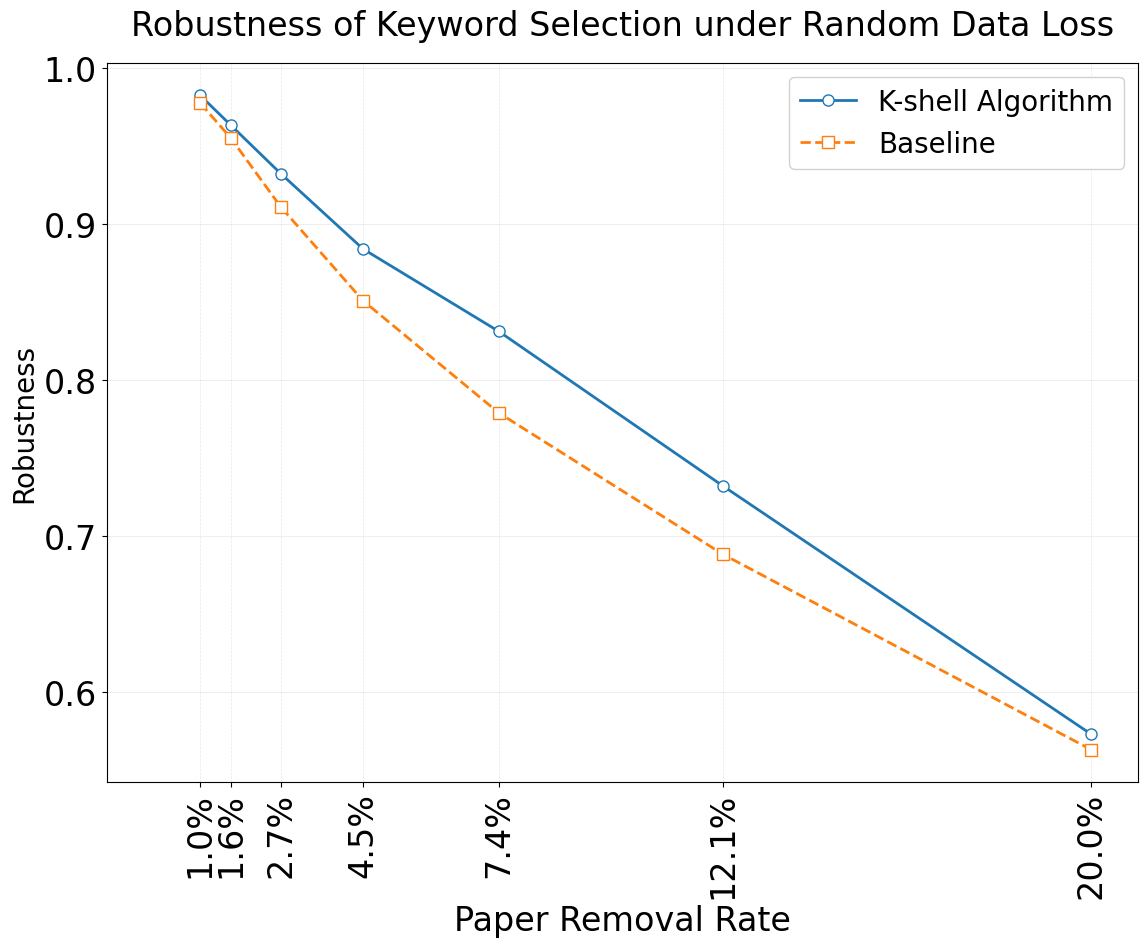

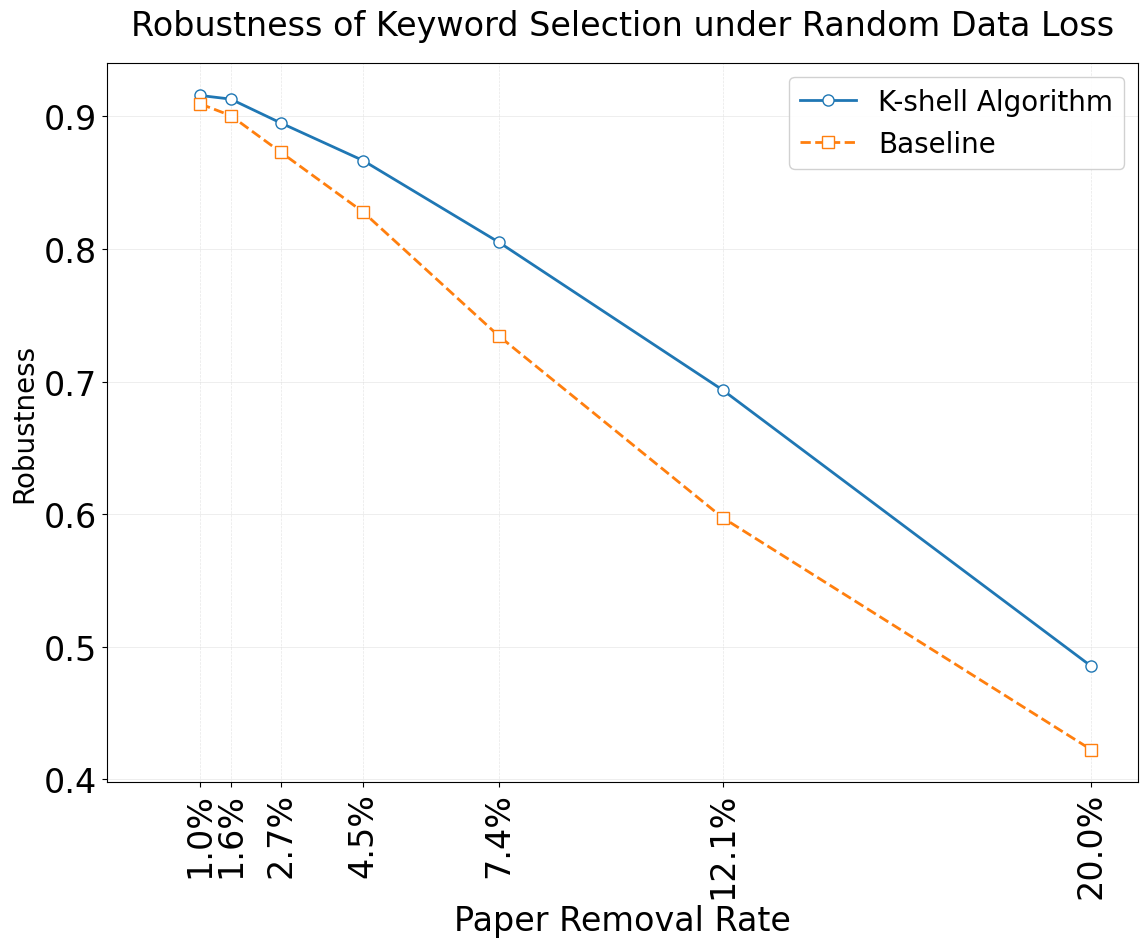

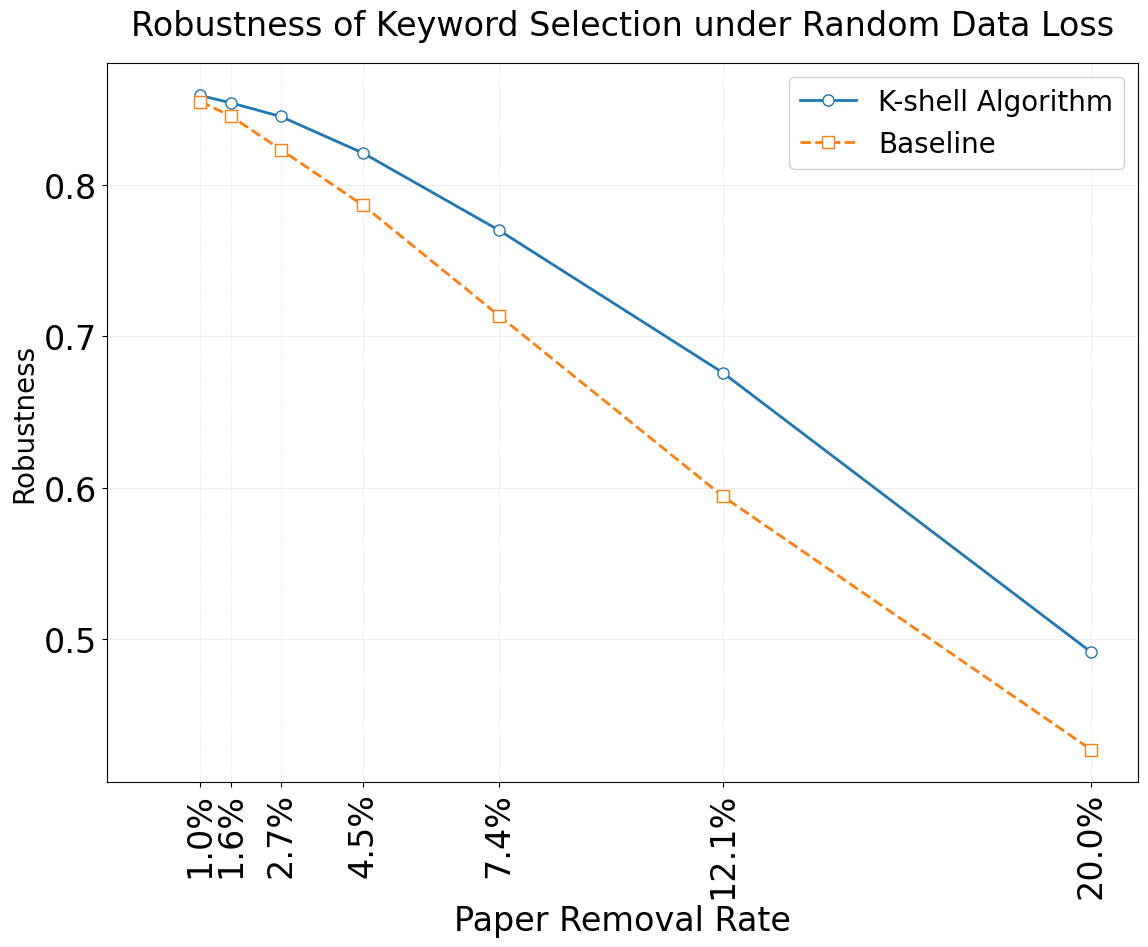

In [4]:
def analyze_stability_across_a(
    a_min=0.0, 
    a_max=0.2, 
    num_points=7, 
    sep=5, 
    t=5, 
    random_seed=42, 
    num_processes=None,
    file_path="topics"
):
    """
    Analyze stability across different paper removal rates (a values)
    
    Args:
        a_min (float): Minimum removal rate (default=0.0)
        a_max (float): Maximum removal rate (default=0.2)
        num_points (int): Number of a values to test
        sep (int): Year span for time windows
        t (int): Number of simulation runs per window
        random_seed (int): Base random seed
        num_processes (int): Number of parallel processes
        
    Returns:
        tuple: (a_values, k_shell_means, dc_means)
    """
    # Generate a values with logarithmic spacing near 0
    a_values = np.logspace(np.log10(0.01), np.log10(a_max), num_points)
    a_values = np.unique(np.sort(a_values))[:num_points]
    
    # Initialize result containers
    k_shell_means = []
    dc_means = []
    
    for a in a_values:
        print(f"Processing a={a:.4f}")
        results = run_stability_analysis(
            a=a,
            t=t,
            sep=sep,
            random_seed=random_seed,
            num_processes=num_processes,
            file_path=file_path,
        )
        
        k_shell_means.append(results['k_shell']['mean'])
        dc_means.append(results['dynamic_count']['mean'])
    
    # Convert to numpy arrays
    a_values = np.array(a_values)
    k_shell_means = np.array(k_shell_means)
    dc_means = np.array(dc_means)
    
    # Create plot with improved formatting
    plt.figure(figsize=(12, 10))
    plt.rcParams.update({'font.size': 24})
    
    # Plot mean stability
    plt.plot(a_values, k_shell_means, '-o', markersize=8, label='K-shell Algorithm', 
             color='#1f77b4', linewidth=2, markerfacecolor='white', markeredgecolor='#1f77b4')
    plt.plot(a_values, dc_means, '--s', markersize=8, label='Baseline', 
             color='#ff7f0e', linewidth=2, markerfacecolor='white', markeredgecolor='#ff7f0e')
    
    # Formatting
    plt.title('Robustness of Keyword Selection under Random Data Loss', fontsize=24, pad=20)
    plt.xlabel('Paper Removal Rate', fontsize=24)
    plt.ylabel('Robustness', fontsize=20)
    plt.legend(fontsize=20, frameon=True, framealpha=0.9, loc='best')
    
    # Custom grid and ticks
    plt.xticks(a_values, [f'{x:.1%}' for x in a_values], rotation=90)
    plt.gca().xaxis.set_ticks_position('bottom')
    plt.gca().yaxis.set_ticks_position('left')
    
    # Add vertical grid lines at each data point
    plt.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
    plt.grid(axis='y', alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Set axis limits
    plt.xlim(a_min-0.01, a_max+0.01)
    
    # Show plot
    plt.tight_layout()
    # plt.show()
    plt.savefig(f"./pic_for_paper/K-shell_{file_path}.pdf")
    
    return a_values, k_shell_means, dc_means


a_values, k_shell_means, dc_means = analyze_stability_across_a(t=5, file_path="topics")
a_values, k_shell_means, dc_means = analyze_stability_across_a(t=5, file_path="topics_lis")
a_values, k_shell_means, dc_means = analyze_stability_across_a(t=5, file_path="topics_soci")

In [5]:
diff = k_shell_means - dc_means
print(k_shell_means)
print(dc_means)
print(diff)
print(a_values)
print("min:", min(diff))
print("max:", max(diff))
print("avg:", np.average(diff))
a_range = (a_values[-1] - a_values[0]) * 10
print(f"slope: K-shell {(k_shell_means[-1] - k_shell_means[0]) / a_range}, \
Baseline: {(dc_means[-1] - dc_means[0]) / a_range}")

[0.85901088 0.85416456 0.8451658  0.8209831  0.77011723 0.67614679
 0.4915973 ]
[0.85498748 0.84553965 0.8233206  0.78654391 0.71374982 0.59459734
 0.42723806]
[0.0040234  0.00862491 0.0218452  0.0344392  0.05636741 0.08154945
 0.06435924]
[0.01       0.01647549 0.02714418 0.04472136 0.07368063 0.12139245
 0.2       ]
min: 0.004023399136468098
max: 0.08154945021701987
avg: 0.038744113920052774
slope: K-shell -0.1933755684447499, Baseline: -0.22513127235542593
